In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from scipy.sparse import load_npz
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

Using Python 3.12.12 environment at: /usr
Resolved 19 packages in 428ms
Prepared 1 package in 2.44s
Installed 1 package in 9ms
 + catboost==1.2.10


In [ ]:
!unzip /content/NLP.zip

Archive:  /content/NLP.zip
   creating: NLP/
  inflating: NLP/ft.npy              
  inflating: NLP/ft_rus.npy          
  inflating: NLP/tag_data.npy        
  inflating: NLP/tone_data.npy       
  inflating: NLP/vectors_sparse_tfidf.npz  
  inflating: NLP/w2v.npy             
  inflating: NLP/w2v_rus.npy         


In [ ]:
pos = pd.read_csv("/content/positive.csv", sep=";", header=None)
pos["label"] = 1
neg = pd.read_csv("/content/negative.csv", sep=";", header=None)
neg["label"] = 0
y = pd.concat([pos, neg])["label"].to_list()

In [ ]:
def test_emb(emb_path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    X = load_npz(emb_path).toarray() if Path(emb_path).suffix == ".npz" else np.load(emb_path)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

    model = CatBoostClassifier(task_type="GPU")
    model.fit(X_train, y_train, logging_level="Silent")

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=[1])
    conf_mat = confusion_matrix(y_test, y_pred)
    return accuracy, prec, rec, f1, conf_mat

In [ ]:
accuracies = []
precisions = []
recalls = []
f1_scores = []
confusion_matrices = []
pathes = list(Path("/content/NLP").glob("*.npy")) + list(Path("/content/NLP").glob("*.npz"))

for path in tqdm(pathes):
    accuracy, prec, rec, f1, conf_mat = test_emb(path)
    accuracies.append(round(accuracy, 4))
    precisions.append(round(prec[0], 4))
    recalls.append(round(rec[0], 4))
    f1_scores.append(round(f1[0], 4))
    confusion_matrices.append(conf_mat)

  0%|          | 0/7 [00:00<?, ?it/s]

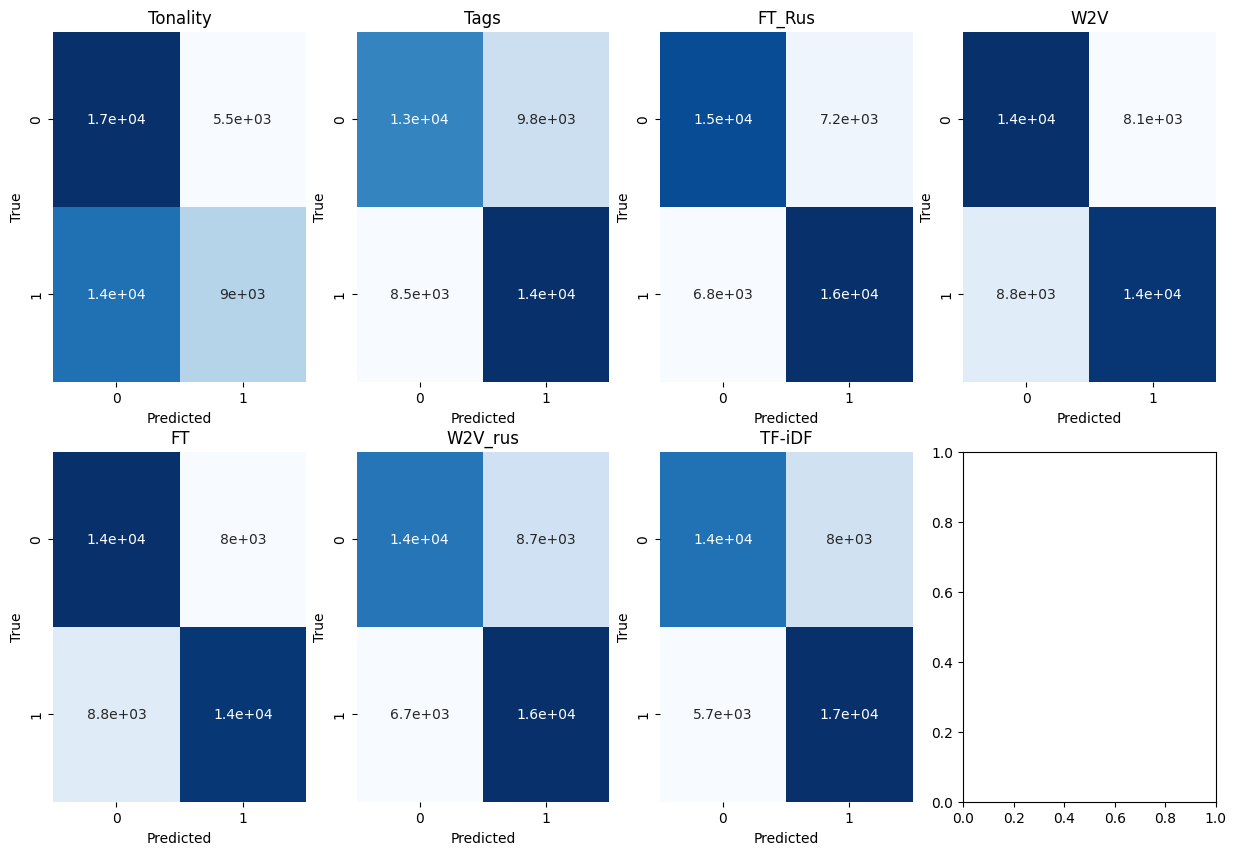

In [ ]:
cols = 4
names = ["Tonality", "Tags", "FT_Rus", "W2V", "FT", "W2V_rus", "TF-iDF"]

fig, axs = plt.subplots(2, cols, figsize=(15, 10))
for i in range(len(confusion_matrices)):
    sns.heatmap(confusion_matrices[i], cmap="Blues", ax=axs[i // cols, i % cols], cbar=False, annot=True)
    axs[i // cols, i % cols].set_title(names[i])
    axs[i // cols, i % cols].set_xlabel("Predicted")
    axs[i // cols, i % cols].set_ylabel("True")

In [ ]:
names = ["Tonality", "Tags", "FT_Rus", "W2V", "FT", "W2V_rus", "TF-iDF"]
df = pd.DataFrame(
    {"embedding": names, "accuracy": accuracies, "precision": precisions, "recall": recalls, "f1": f1_scores}
)
df

,embedding,accuracy,precision,recall,f1
0,Tonality,0.5690,0.6184,0.3896,0.4780
1,Tags,0.5955,0.5953,0.6297,0.6120
2,FT_Rus,0.6930,0.6935,0.7060,0.6997
3,W2V,0.6291,0.6383,0.6182,0.6281
4,FT,0.6295,0.6391,0.6173,0.6280
5,W2V_rus,0.6607,0.6522,0.7078,0.6788
6,TF-iDF,0.6979,0.6834,0.7519,0.7160


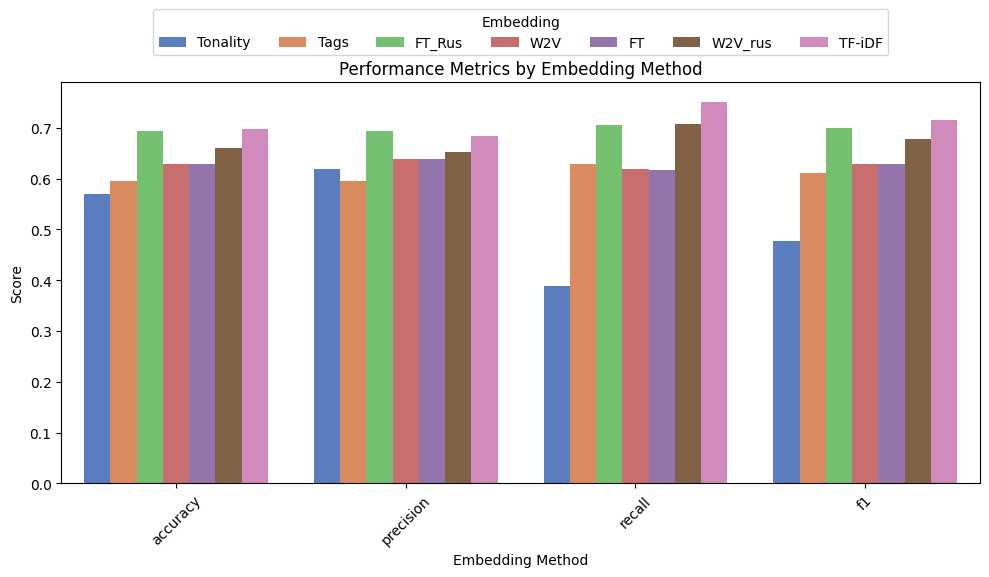

In [ ]:
df_melted = df.melt(id_vars="embedding", var_name="metric", value_name="score")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="metric", y="score", hue="embedding", palette="muted")

plt.title("Performance Metrics by Embedding Method")
plt.ylabel("Score")
plt.xlabel("Embedding Method")
plt.legend(title="Embedding", bbox_to_anchor=(0.5, 1.20), loc="upper center", ncol=len(names))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()